Imports

In [1]:
import importlib
import importlib.machinery
import io
import os
import sys
import types
import uuid
from datetime import datetime
from pathlib import Path

import cv2
import duckdb
import faiss
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import polars as pl
import requests
import torch
from PIL import Image
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoProcessor,
    CLIPModel,
    CLIPProcessor,
)
from ultralytics import YOLO

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

c:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef\bachproef26\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


Variabelen

In [44]:
MODEL_PATH = "yolo11s.pt"   
# MODEL_PATH = "yolov8n.pt"

IMAGE_PATH = (
    r"C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef"
    r"\bachproef26\latex-hogent-bachproef\bachproef\datasets"
    r"\SKU-110K_fixed\images\test_168.jpg"
)

PARQUET_PATH = (
    r"C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef"
    r"\bachproef26\latex-hogent-bachproef\bachproef\datasets\food_images_long.parquet"
)

CROPS_ROOT   = "./crops"
INDEX_CACHE = r"C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef\bachproef26\latex-hogent-bachproef\bachproef\faiss_index.bin"
META_CACHE  = r"C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef\bachproef26\latex-hogent-bachproef\bachproef\datasets\faiss_meta.parquet"

CLIP_WEIGHT  = 1
FL2_WEIGHT   = 0

CONF         = 0.25  
TOP_K        = 5    

print("Variabelen ingeladen")

Variabelen ingeladen


Modellen inladen

In [45]:
#Florence-2
flash_attn = types.ModuleType("flash_attn")
flash_attn.__spec__ = importlib.machinery.ModuleSpec("flash_attn", None)
flash_attn_interface = types.ModuleType("flash_attn.flash_attn_interface")
flash_attn_interface.__spec__ = importlib.machinery.ModuleSpec("flash_attn.flash_attn_interface", None)
sys.modules["flash_attn"] = flash_attn
sys.modules["flash_attn.flash_attn_interface"] = flash_attn_interface
os.environ["FLASH_ATTENTION_FORCE_DISABLED"] = "1"

fl2_model_id  = "microsoft/Florence-2-base"
fl2_processor = AutoProcessor.from_pretrained(fl2_model_id, trust_remote_code=True)
fl2_model     = AutoModelForCausalLM.from_pretrained(
    fl2_model_id, trust_remote_code=True, attn_implementation="eager"
).to(device)
fl2_model.eval()
print("Florence-2 loaded")

# CLIP
clip_model_id  = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_id).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_model_id)
clip_model.eval()
print("CLIP loaded")

#YOLO
yolo = YOLO(MODEL_PATH)
print("YOLO loaded")

Florence-2 loaded
CLIP loaded
YOLO loaded


Embedding

In [46]:
@torch.no_grad()
def clip_embed(pil_image: Image.Image) -> np.ndarray:
    """Returns a normalised CLIP visual embedding (512-d)."""
    inputs = clip_processor(images=pil_image, return_tensors="pt").to(device)
    feats  = clip_model.get_image_features(**inputs)          # (1, 512)
    vec    = feats.squeeze().cpu().float().numpy()
    return vec / (np.linalg.norm(vec) + 1e-9)


@torch.no_grad()
def fl2_embed(pil_image: Image.Image) -> np.ndarray:
    """Florence-2 visual embedding — uses _encode_image which is the correct internal API."""
    pixel_values = fl2_processor(images=pil_image, return_tensors="pt").pixel_values.to(device)
    
    visual_feats = fl2_model._encode_image(pixel_values)  # (1, num_tokens, lm_hidden)
    
    vec = visual_feats.mean(dim=1).squeeze().cpu().float().numpy()
    return vec / (np.linalg.norm(vec) + 1e-9)


def fused_embed(pil_image: Image.Image) -> np.ndarray:
    """
    Weighted fusion of CLIP + Florence-2 embeddings.
    Both parts are normalised individually before fusion,
    then the result is L2-normalised again.
    """
    c = clip_embed(pil_image) 
    f = fl2_embed(pil_image)   

    fused = np.concatenate([CLIP_WEIGHT * c, FL2_WEIGHT * f])
    return fused / (np.linalg.norm(fused) + 1e-9)


EMBED_DIM = 512 + 768   
print(f"Fused embedding dim: {EMBED_DIM}")

Fused embedding dim: 1280


OpenFoodFacts dataset inladen

In [47]:
df_foodfacts = duckdb.query(f"""
    SELECT DISTINCT ON (product_name) *
    FROM '{PARQUET_PATH}'
    WHERE image_key LIKE '%front%'
""").pl()

print(f"Rows    : {len(df_foodfacts):,}")
print(f"Columns : {df_foodfacts.columns}")
df_foodfacts.head(500)

Rows    : 46,461
Columns : ['code', 'product_name', 'image_key', 'image_url']


code,product_name,image_key,image_url
str,str,str,str
"""0024000124948""","""Melocotón mitades en zumo""","""front_fi""","""https://images.openfoodfacts.o…"
"""0613008736194""","""Original Green tea with honey""","""front_fr""","""https://images.openfoodfacts.o…"
"""0640700003224""","""Roasted White Sesame Seeds""","""front_fr""","""https://images.openfoodfacts.o…"
"""0643431247103""","""After Eight""","""front_fr""","""https://images.openfoodfacts.o…"
"""0898999000206""","""Coconut Water With Pineapple""","""front_en""","""https://images.openfoodfacts.o…"
…,…,…,…
"""5400101495470""","""Carrefour Extra Massepain 50% …","""front_fr""","""https://images.openfoodfacts.o…"
"""5400101007222""","""Matière grasse végétale""","""front_fr""","""https://images.openfoodfacts.o…"
"""20771867""","""Plat de poivrons""","""front_fr""","""https://images.openfoodfacts.o…"


FAISS inladen indien in cache anders builden

In [21]:
img = fetch_pil("https://images.openfoodfacts.org/images/products/000/000/001/1754/front_fr.27.400.jpg")
print(fl2_embed(img).shape)

(768,)


In [22]:
# Run this on a single image to see the actual crash
test_url = "https://images.openfoodfacts.org/images/products/000/000/001/1754/front_fr.27.400.jpg"
img = fetch_pil(test_url)
print("Image:", img.size)

# Test each embed step individually
print("\nTesting CLIP...")
vec_clip = clip_embed(img)
print("CLIP OK:", vec_clip.shape)

print("\nTesting Florence-2...")
vec_fl2 = fl2_embed(img)
print("FL2 OK:", vec_fl2.shape)

print("\nTesting fused...")
vec = fused_embed(img)
print("Fused OK:", vec.shape)

Image: (300, 400)

Testing CLIP...
CLIP OK: (512,)

Testing Florence-2...
FL2 OK: (768,)

Testing fused...
Fused OK: (1280,)


In [ ]:
# for f in [INDEX_CACHE, META_CACHE]:
#     if Path(f).exists():
#         os.remove(f)
#         print(f"Deleted: {f}")

In [48]:
def fetch_pil(url: str, timeout: int = 10):
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        return Image.open(io.BytesIO(r.content)).convert("RGB")
    except Exception:
        return None


PROGRESS_DIR = Path("./faiss_progress")

def build_index_resumable(df: pl.DataFrame) -> tuple[faiss.Index, pl.DataFrame]:
    PROGRESS_DIR.mkdir(exist_ok=True)

    embeddings = []
    valid_rows = []
    n_ok = n_skip = n_fail = 0

    for i, row in enumerate(tqdm(df.iter_rows(named=True), total=len(df), desc="Embedding")):
        cache_file = PROGRESS_DIR / f"row_{i:07d}.npy"

        if cache_file.exists():
            embeddings.append(np.load(str(cache_file)))
            valid_rows.append(row)
            n_skip += 1
            continue

        url = row.get("image_url") or row.get("url") or ""
        img = fetch_pil(url)
        if img is None:
            continue

        try:
            vec = fused_embed(img)
            np.save(str(cache_file), vec)
            embeddings.append(vec)
            valid_rows.append(row)
            n_ok += 1
        except Exception as e:
            n_fail += 1
            if n_fail <= 3:
                print(f"  [embed error] row {i}: {type(e).__name__}: {e}")

    print(f"\nDone — {n_ok} new  |  {n_skip} resumed  |  {n_fail} failed")

    if not embeddings:
        raise RuntimeError("No embeddings — check fl2_embed works first.")

    matrix = np.stack(embeddings).astype("float32")
    index  = faiss.IndexFlatIP(EMBED_DIM)
    index.add(matrix)
    return index, pl.DataFrame(valid_rows)


Path(INDEX_CACHE).unlink(missing_ok=True)
Path(META_CACHE).unlink(missing_ok=True)

print("Building index (skips already embedded rows) …")
index, meta_df = build_index_resumable(df_foodfacts)
faiss.write_index(index, INDEX_CACHE)
meta_df.write_parquet(META_CACHE)
print(f"Saved: {index.ntotal:,} vectors")

Building index (skips already embedded rows) …


Embedding:   7%|▋         | 3465/46461 [20:16<4:11:37,  2.85it/s] 


KeyboardInterrupt: 

YOLO + croppen -> embedding -> match zoeken

In [36]:
# input afbeelding inladen
image_path = Path(IMAGE_PATH)
assert image_path.exists(), f"Image not found: {image_path}"

img_bgr = cv2.imread(str(image_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w    = img_bgr.shape[:2]

# YOLO runnen
results = yolo.predict(source=str(image_path), conf=CONF, verbose=False)
boxes   = results[0].boxes
n_det   = 0 if boxes is None else len(boxes)
print(f"Detections: {n_det}")

# output folder maken zodat het opgeslagen kan worden
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
short_uid = uuid.uuid4().hex[:8]
run_dir   = Path(CROPS_ROOT) / f"{timestamp}_{short_uid}"
run_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {run_dir.resolve()}")

Detections: 16
Output dir: C:\Users\krist\Documents\Hogent_IT\3de_jaar\Bachelorproef\bachproef26\latex-hogent-bachproef\bachproef\crops\20260502_215143_114f9f41


Elke crop processen en match vinden, geeft top-K matches

In [37]:
def search(pil_image: Image.Image, k: int = TOP_K):
    """Embed pil_image, query FAISS, return (scores, metadata rows)."""
    vec        = fused_embed(pil_image).reshape(1, -1).astype("float32")
    scores, idxs = index.search(vec, k)
    scores, idxs = scores[0], idxs[0]

    matches = []
    for score, idx in zip(scores, idxs):
        if idx == -1:
            continue
        row = meta_df.row(idx, named=True)
        matches.append({
            "similarity"   : float(score),
            "code"         : row.get("code"),
            "product_name" : row.get("product_name"),
            "image_url"    : row.get("image_url") or row.get("url"),
        })
    return matches


all_results = [] 

for i, box in enumerate(tqdm(boxes, desc="Processing crops")):
    # ── Crop ──────────────────────────────────────────────────────────────────
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    x1 = max(0, int(round(x1)))
    y1 = max(0, int(round(y1)))
    x2 = min(w, int(round(x2)))
    y2 = min(h, int(round(y2)))

    if x2 <= x1 or y2 <= y1:
        continue

    conf_val   = float(box.conf[0])
    crop_bgr   = img_bgr[y1:y2, x1:x2]
    crop_pil   = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))

    # ── Save crop ─────────────────────────────────────────────────────────────
    crop_name  = f"{i:04d}_conf{conf_val:.2f}.jpg"
    crop_path  = run_dir / crop_name
    crop_pil.save(str(crop_path))

    # ── Match ─────────────────────────────────────────────────────────────────
    matches = search(crop_pil)
    all_results.append((crop_pil, crop_path, matches))

print(f"\nDone. Processed {len(all_results)} crop(s).")

Processing crops: 100%|██████████| 16/16 [00:02<00:00,  5.98it/s]


Done. Processed 16 crop(s).


Resultaten visualiseren

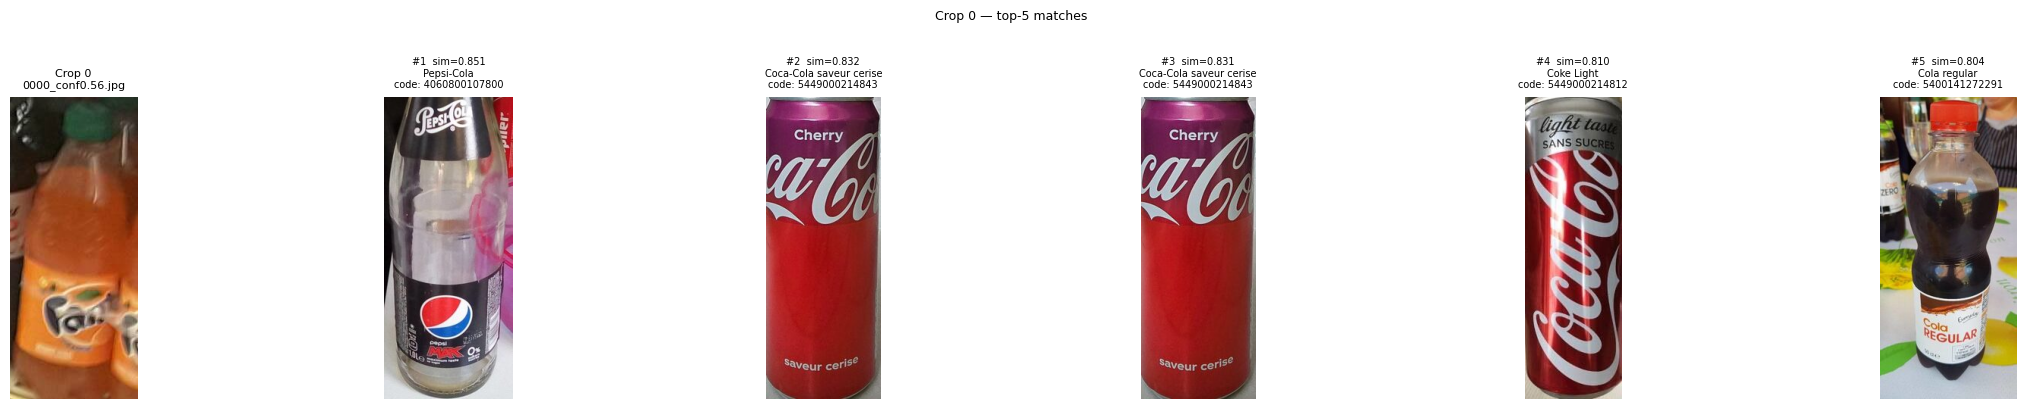


  Crop 0 best matches:
    #1  sim=0.8509  code=4060800107800  name=Pepsi-Cola
         url=https://images.openfoodfacts.org/images/products/406/080/010/7800/front_fr.12.400.jpg
    #2  sim=0.8317  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/front_fr.74.400.jpg
    #3  sim=0.8314  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/18.400.jpg
    #4  sim=0.8100  code=5449000214812  name=Coke Light
         url=https://images.openfoodfacts.org/images/products/544/900/021/4812/8.400.jpg
    #5  sim=0.8040  code=5400141272291  name=Cola regular
         url=https://images.openfoodfacts.org/images/products/540/014/127/2291/front_fr.4.400.jpg



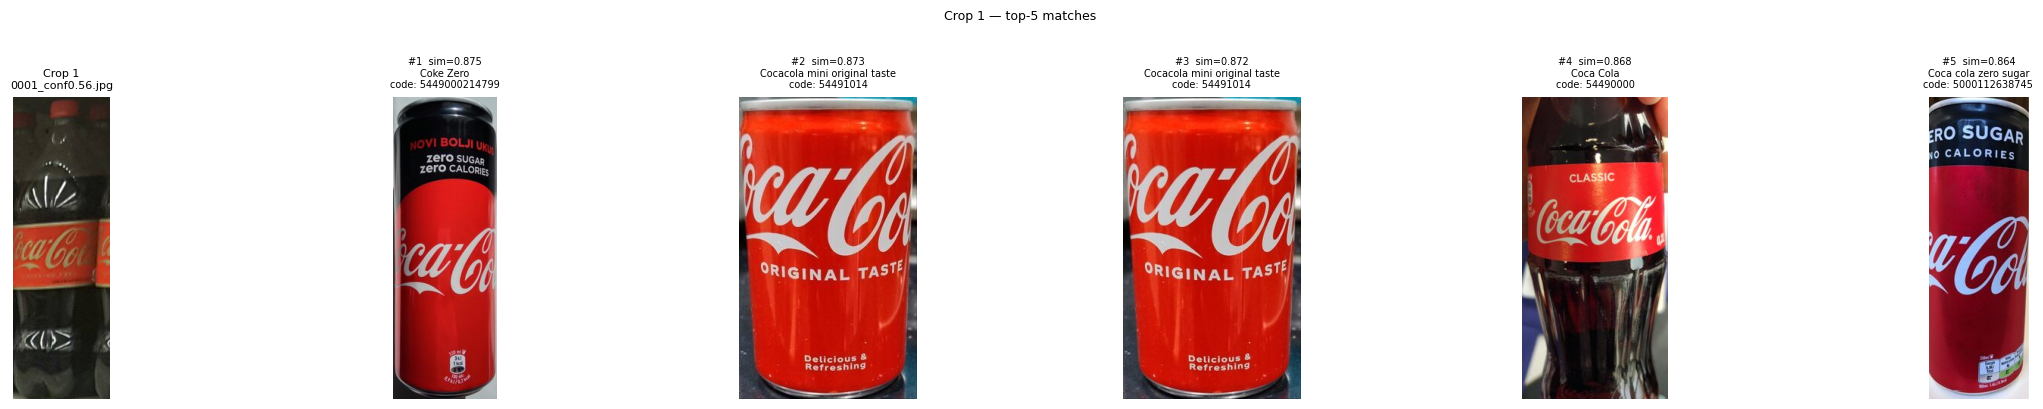


  Crop 1 best matches:
    #1  sim=0.8753  code=5449000214799  name=Coke Zero
         url=https://images.openfoodfacts.org/images/products/544/900/021/4799/front_sr.41.400.jpg
    #2  sim=0.8731  code=54491014  name=Cocacola mini original taste
         url=https://images.openfoodfacts.org/images/products/000/005/449/1014/45.400.jpg
    #3  sim=0.8725  code=54491014  name=Cocacola mini original taste
         url=https://images.openfoodfacts.org/images/products/000/005/449/1014/42.400.jpg
    #4  sim=0.8675  code=54490000  name=Coca Cola
         url=https://images.openfoodfacts.org/images/products/000/005/449/0000/front_fr.20.400.jpg
    #5  sim=0.8642  code=5000112638745  name=Coca cola zero sugar
         url=https://images.openfoodfacts.org/images/products/500/011/263/8745/front_fr.4.400.jpg



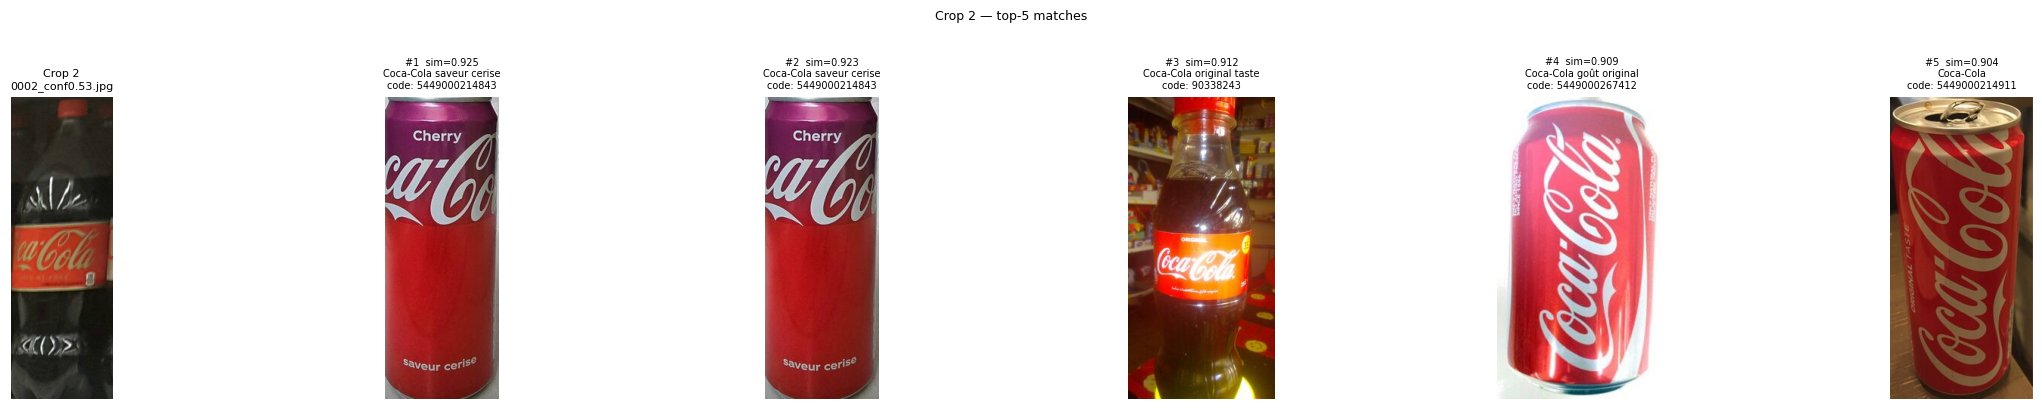


  Crop 2 best matches:
    #1  sim=0.9255  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/front_fr.74.400.jpg
    #2  sim=0.9229  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/18.400.jpg
    #3  sim=0.9121  code=90338243  name=Coca-Cola original taste
         url=https://images.openfoodfacts.org/images/products/000/009/033/8243/9.400.jpg
    #4  sim=0.9092  code=5449000267412  name=Coca-Cola goût original
         url=https://images.openfoodfacts.org/images/products/544/900/026/7412/11.400.jpg
    #5  sim=0.9043  code=5449000214911  name=Coca-Cola
         url=https://images.openfoodfacts.org/images/products/544/900/021/4911/52.400.jpg



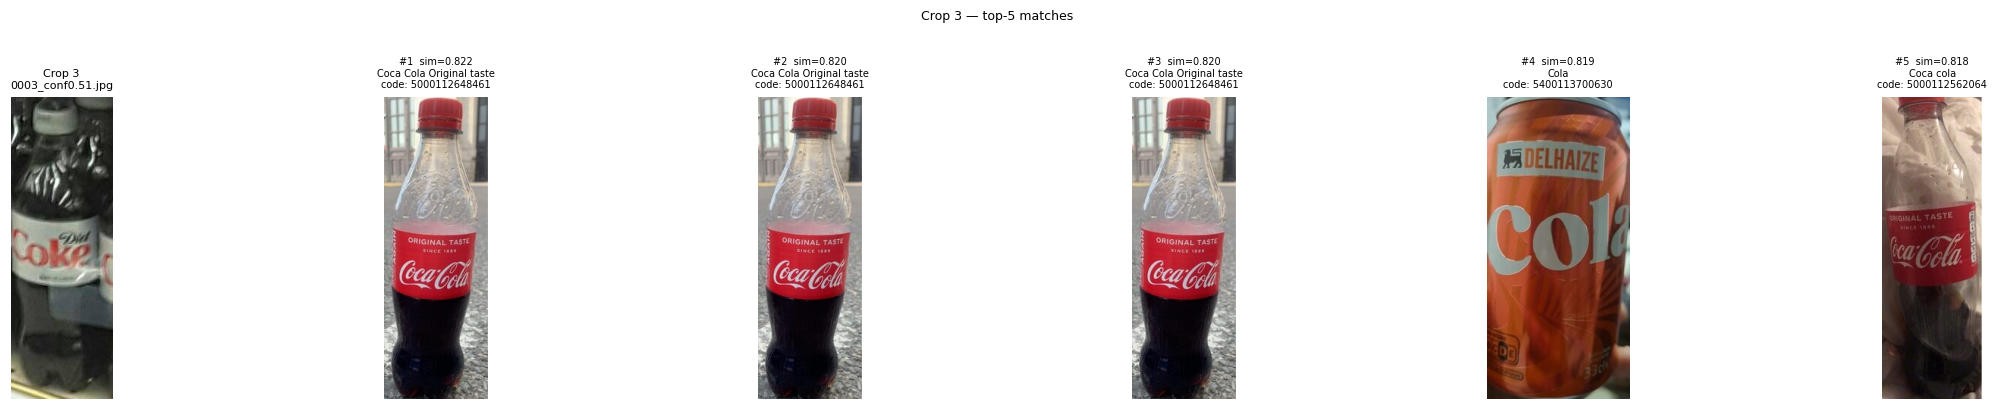


  Crop 3 best matches:
    #1  sim=0.8217  code=5000112648461  name=Coca Cola Original taste
         url=https://images.openfoodfacts.org/images/products/500/011/264/8461/front_fr.5.400.jpg
    #2  sim=0.8205  code=5000112648461  name=Coca Cola Original taste
         url=https://images.openfoodfacts.org/images/products/500/011/264/8461/1.400.jpg
    #3  sim=0.8198  code=5000112648461  name=Coca Cola Original taste
         url=https://images.openfoodfacts.org/images/products/500/011/264/8461/front_nl.27.400.jpg
    #4  sim=0.8194  code=5400113700630  name=Cola
         url=https://images.openfoodfacts.org/images/products/540/011/370/0630/front_fr.11.400.jpg
    #5  sim=0.8185  code=5000112562064  name=Coca cola
         url=https://images.openfoodfacts.org/images/products/500/011/256/2064/front_fr.6.400.jpg



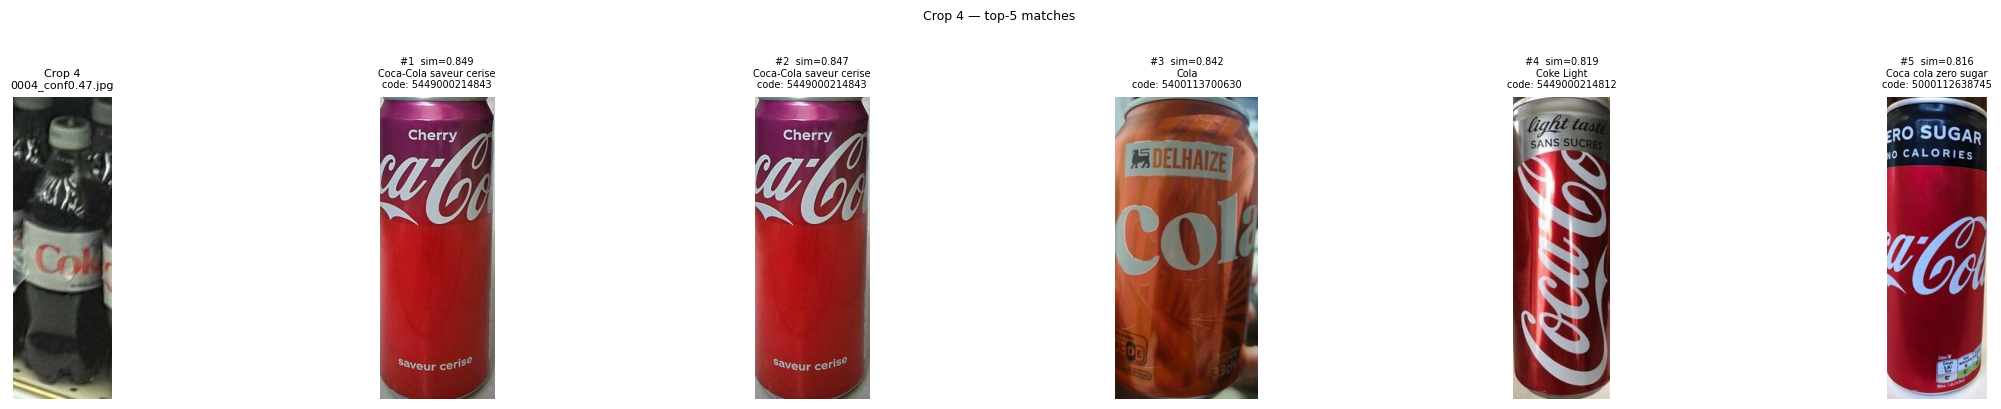


  Crop 4 best matches:
    #1  sim=0.8487  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/front_fr.74.400.jpg
    #2  sim=0.8473  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/18.400.jpg
    #3  sim=0.8423  code=5400113700630  name=Cola
         url=https://images.openfoodfacts.org/images/products/540/011/370/0630/front_fr.11.400.jpg
    #4  sim=0.8192  code=5449000214812  name=Coke Light
         url=https://images.openfoodfacts.org/images/products/544/900/021/4812/8.400.jpg
    #5  sim=0.8159  code=5000112638745  name=Coca cola zero sugar
         url=https://images.openfoodfacts.org/images/products/500/011/263/8745/front_fr.4.400.jpg



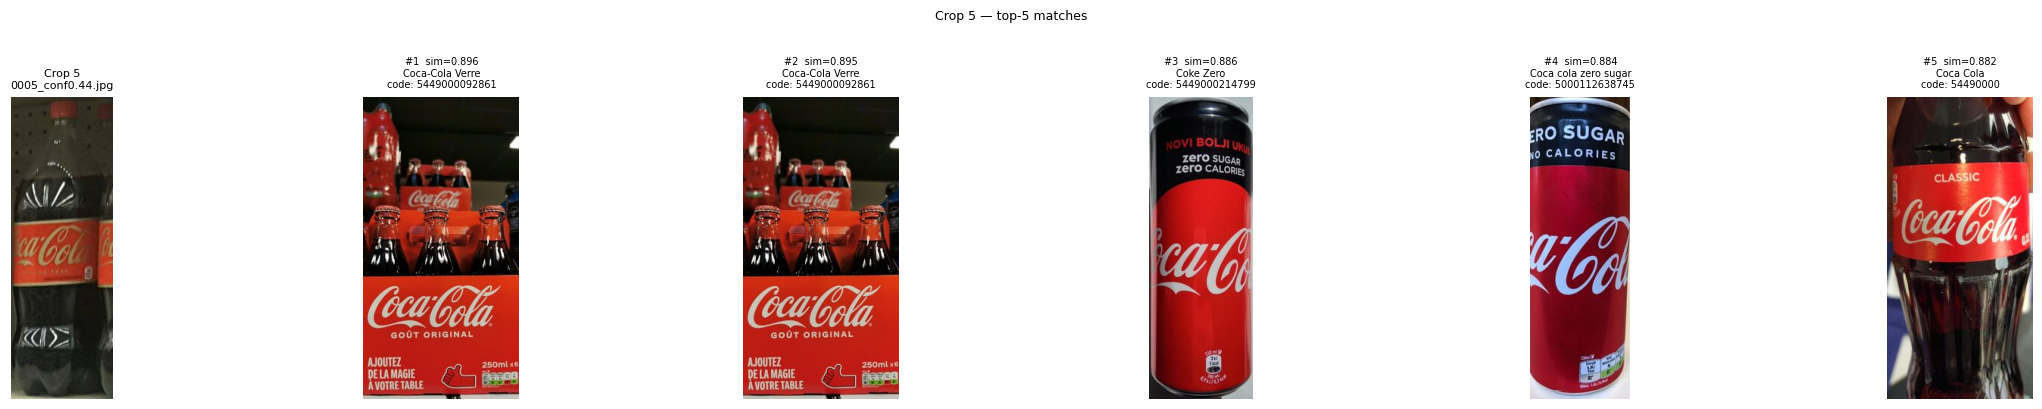


  Crop 5 best matches:
    #1  sim=0.8955  code=5449000092861  name=Coca-Cola Verre
         url=https://images.openfoodfacts.org/images/products/544/900/009/2861/3.400.jpg
    #2  sim=0.8950  code=5449000092861  name=Coca-Cola Verre
         url=https://images.openfoodfacts.org/images/products/544/900/009/2861/front_fr.18.400.jpg
    #3  sim=0.8858  code=5449000214799  name=Coke Zero
         url=https://images.openfoodfacts.org/images/products/544/900/021/4799/front_sr.41.400.jpg
    #4  sim=0.8843  code=5000112638745  name=Coca cola zero sugar
         url=https://images.openfoodfacts.org/images/products/500/011/263/8745/front_fr.4.400.jpg
    #5  sim=0.8816  code=54490000  name=Coca Cola
         url=https://images.openfoodfacts.org/images/products/000/005/449/0000/front_fr.20.400.jpg



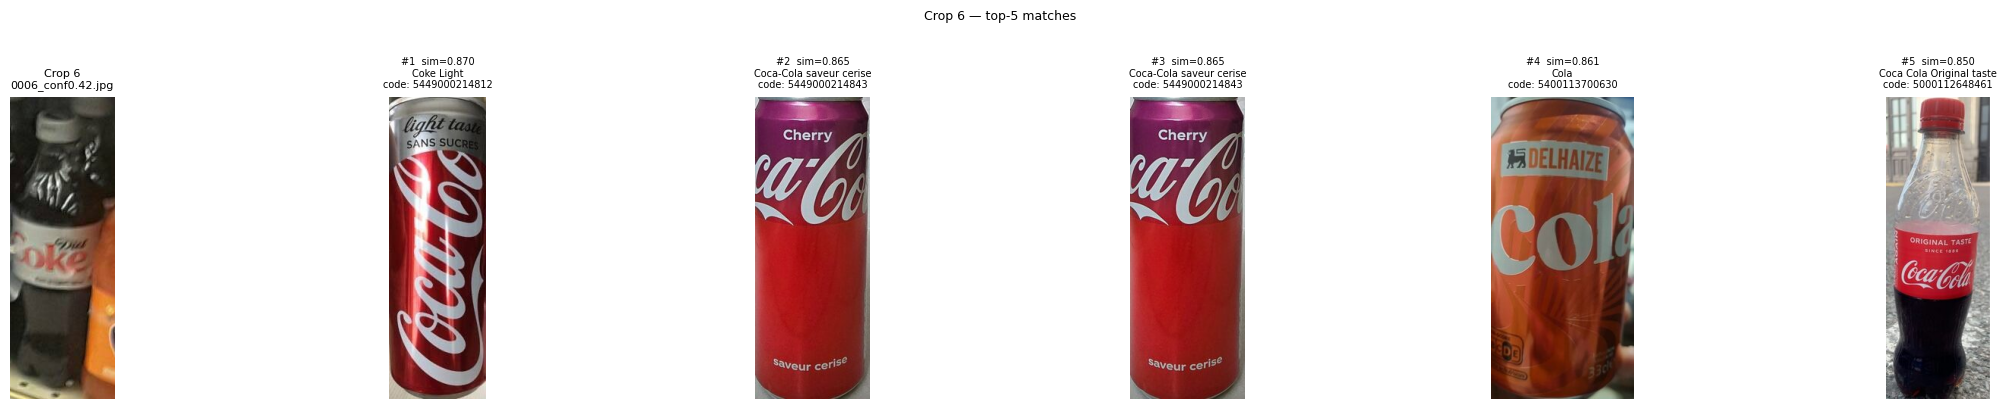


  Crop 6 best matches:
    #1  sim=0.8703  code=5449000214812  name=Coke Light
         url=https://images.openfoodfacts.org/images/products/544/900/021/4812/8.400.jpg
    #2  sim=0.8653  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/front_fr.74.400.jpg
    #3  sim=0.8646  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/18.400.jpg
    #4  sim=0.8614  code=5400113700630  name=Cola
         url=https://images.openfoodfacts.org/images/products/540/011/370/0630/front_fr.11.400.jpg
    #5  sim=0.8500  code=5000112648461  name=Coca Cola Original taste
         url=https://images.openfoodfacts.org/images/products/500/011/264/8461/1.400.jpg



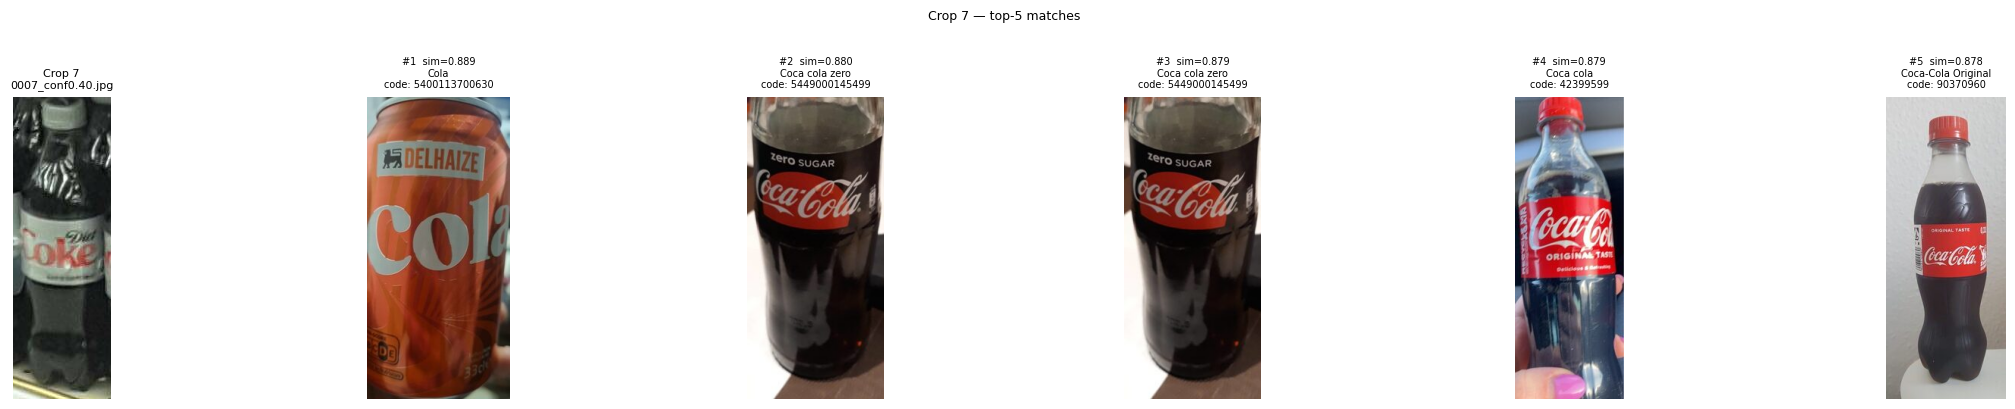


  Crop 7 best matches:
    #1  sim=0.8892  code=5400113700630  name=Cola
         url=https://images.openfoodfacts.org/images/products/540/011/370/0630/front_fr.11.400.jpg
    #2  sim=0.8803  code=5449000145499  name=Coca cola zero
         url=https://images.openfoodfacts.org/images/products/544/900/014/5499/front_fr.4.400.jpg
    #3  sim=0.8790  code=5449000145499  name=Coca cola zero
         url=https://images.openfoodfacts.org/images/products/544/900/014/5499/1.400.jpg
    #4  sim=0.8786  code=42399599  name=Coca cola
         url=https://images.openfoodfacts.org/images/products/000/004/239/9599/front_fr.3.400.jpg
    #5  sim=0.8776  code=90370960  name=Coca-Cola Original
         url=https://images.openfoodfacts.org/images/products/000/009/037/0960/8.400.jpg



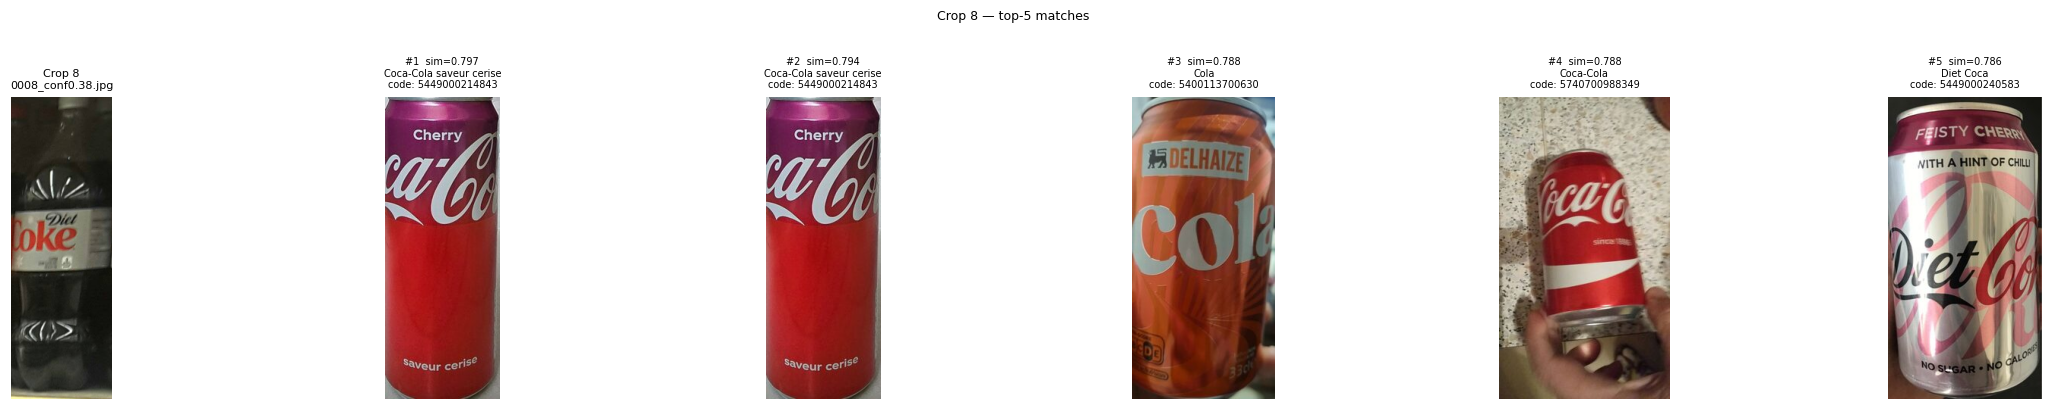


  Crop 8 best matches:
    #1  sim=0.7970  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/front_fr.74.400.jpg
    #2  sim=0.7940  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/18.400.jpg
    #3  sim=0.7878  code=5400113700630  name=Cola
         url=https://images.openfoodfacts.org/images/products/540/011/370/0630/front_fr.11.400.jpg
    #4  sim=0.7876  code=5740700988349  name=Coca-Cola
         url=https://images.openfoodfacts.org/images/products/574/070/098/8349/8.400.jpg
    #5  sim=0.7856  code=5449000240583  name=Diet Coca
         url=https://images.openfoodfacts.org/images/products/544/900/024/0583/front_fr.4.400.jpg



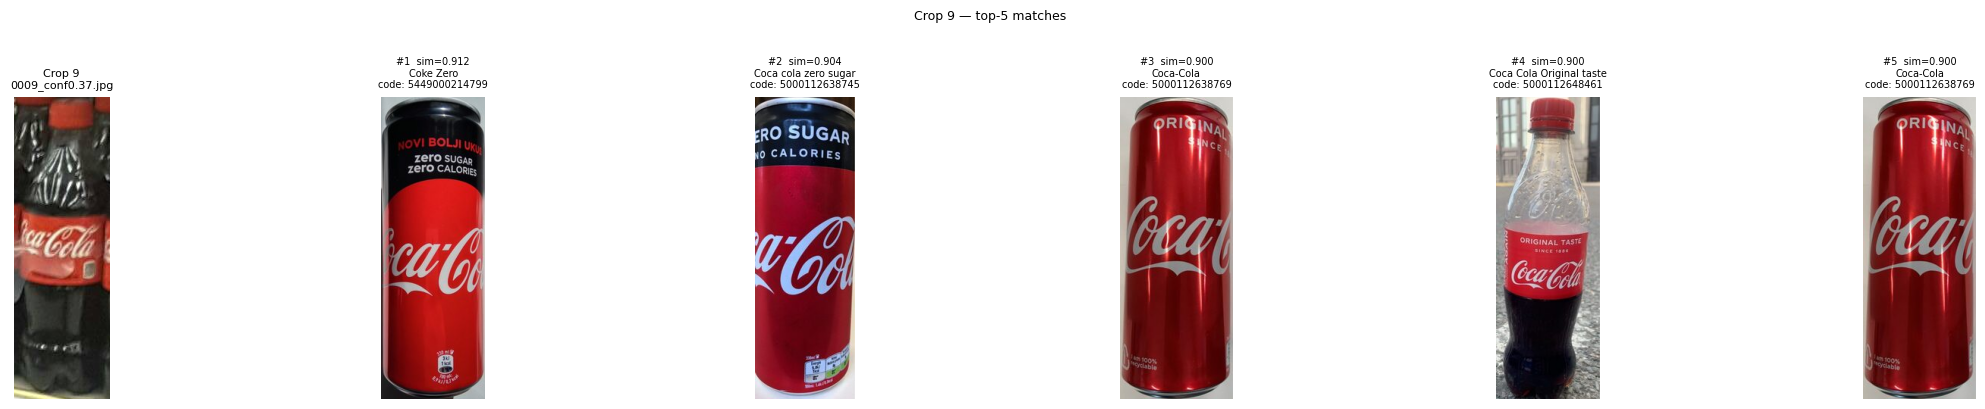


  Crop 9 best matches:
    #1  sim=0.9116  code=5449000214799  name=Coke Zero
         url=https://images.openfoodfacts.org/images/products/544/900/021/4799/front_sr.41.400.jpg
    #2  sim=0.9037  code=5000112638745  name=Coca cola zero sugar
         url=https://images.openfoodfacts.org/images/products/500/011/263/8745/front_fr.4.400.jpg
    #3  sim=0.9003  code=5000112638769  name=Coca-Cola
         url=https://images.openfoodfacts.org/images/products/500/011/263/8769/3.400.jpg
    #4  sim=0.9001  code=5000112648461  name=Coca Cola Original taste
         url=https://images.openfoodfacts.org/images/products/500/011/264/8461/front_fr.5.400.jpg
    #5  sim=0.8998  code=5000112638769  name=Coca-Cola
         url=https://images.openfoodfacts.org/images/products/500/011/263/8769/1.400.jpg



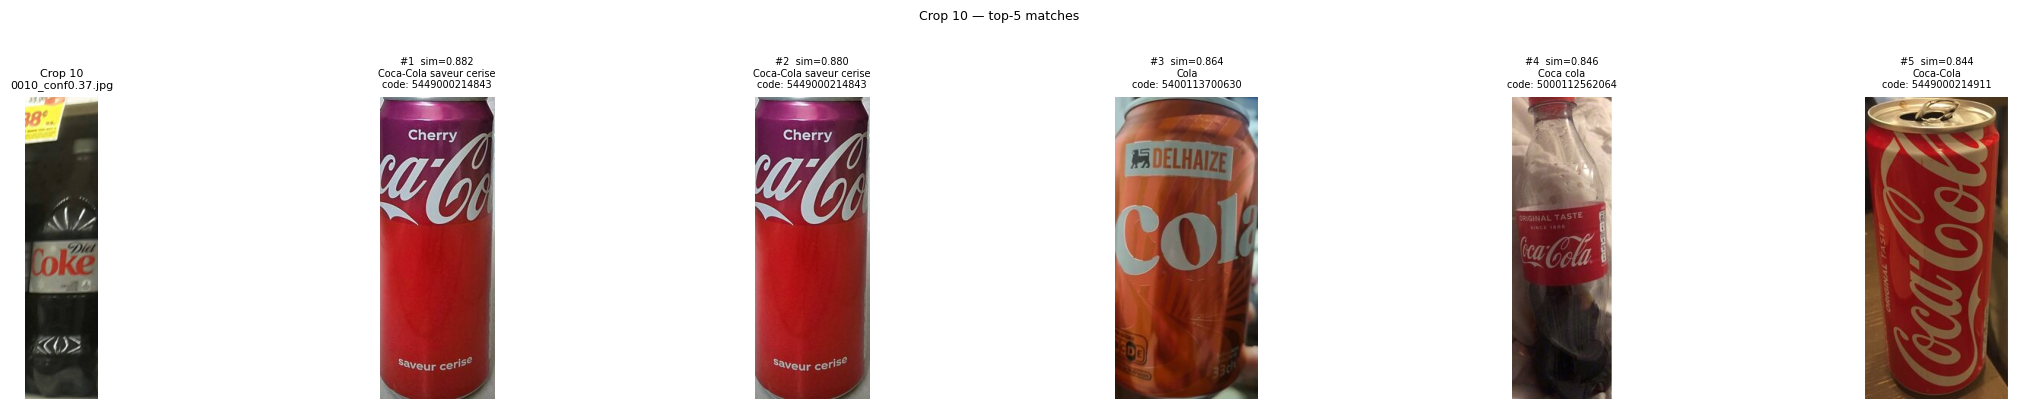


  Crop 10 best matches:
    #1  sim=0.8819  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/front_fr.74.400.jpg
    #2  sim=0.8797  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/18.400.jpg
    #3  sim=0.8640  code=5400113700630  name=Cola
         url=https://images.openfoodfacts.org/images/products/540/011/370/0630/front_fr.11.400.jpg
    #4  sim=0.8456  code=5000112562064  name=Coca cola
         url=https://images.openfoodfacts.org/images/products/500/011/256/2064/front_fr.6.400.jpg
    #5  sim=0.8441  code=5449000214911  name=Coca-Cola
         url=https://images.openfoodfacts.org/images/products/544/900/021/4911/52.400.jpg



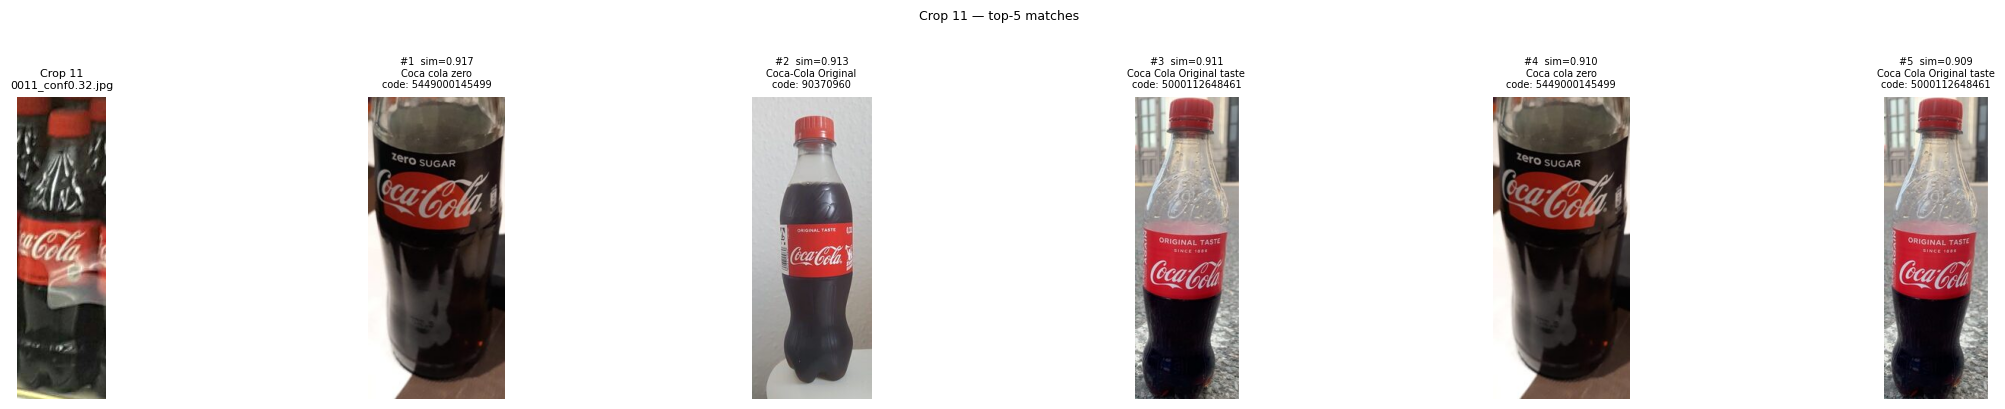


  Crop 11 best matches:
    #1  sim=0.9173  code=5449000145499  name=Coca cola zero
         url=https://images.openfoodfacts.org/images/products/544/900/014/5499/front_fr.4.400.jpg
    #2  sim=0.9130  code=90370960  name=Coca-Cola Original
         url=https://images.openfoodfacts.org/images/products/000/009/037/0960/8.400.jpg
    #3  sim=0.9106  code=5000112648461  name=Coca Cola Original taste
         url=https://images.openfoodfacts.org/images/products/500/011/264/8461/front_fr.5.400.jpg
    #4  sim=0.9097  code=5449000145499  name=Coca cola zero
         url=https://images.openfoodfacts.org/images/products/544/900/014/5499/1.400.jpg
    #5  sim=0.9095  code=5000112648461  name=Coca Cola Original taste
         url=https://images.openfoodfacts.org/images/products/500/011/264/8461/1.400.jpg



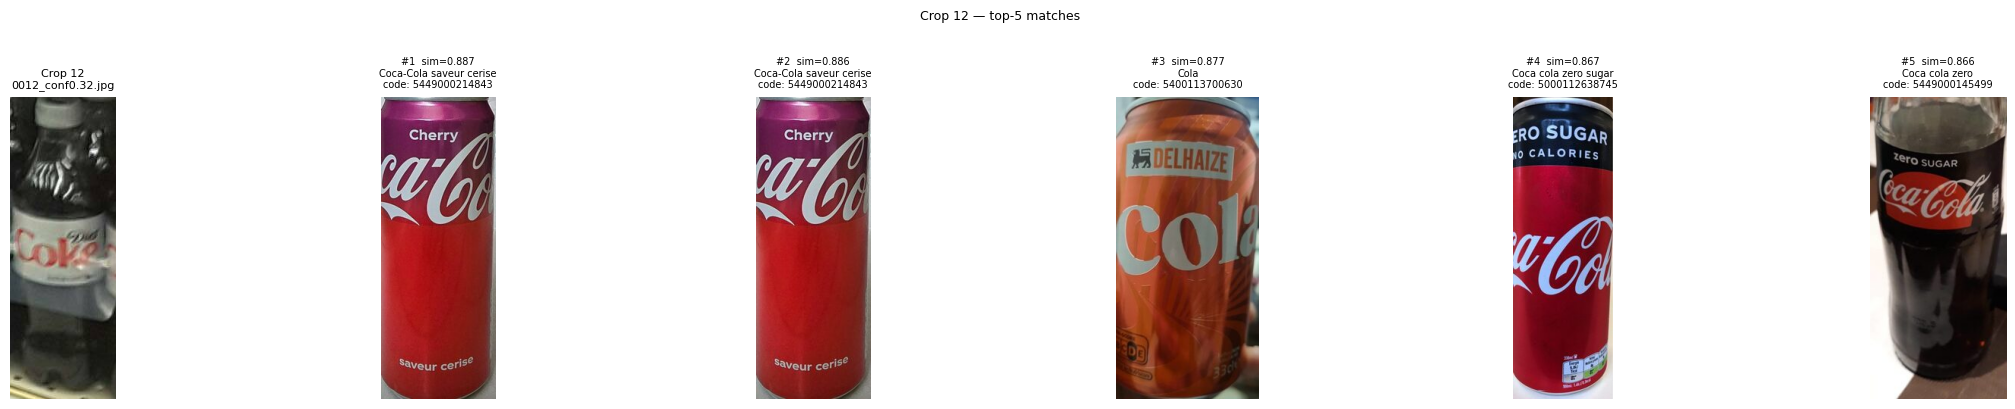


  Crop 12 best matches:
    #1  sim=0.8875  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/front_fr.74.400.jpg
    #2  sim=0.8864  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/18.400.jpg
    #3  sim=0.8766  code=5400113700630  name=Cola
         url=https://images.openfoodfacts.org/images/products/540/011/370/0630/front_fr.11.400.jpg
    #4  sim=0.8668  code=5000112638745  name=Coca cola zero sugar
         url=https://images.openfoodfacts.org/images/products/500/011/263/8745/front_fr.4.400.jpg
    #5  sim=0.8660  code=5449000145499  name=Coca cola zero
         url=https://images.openfoodfacts.org/images/products/544/900/014/5499/front_fr.4.400.jpg



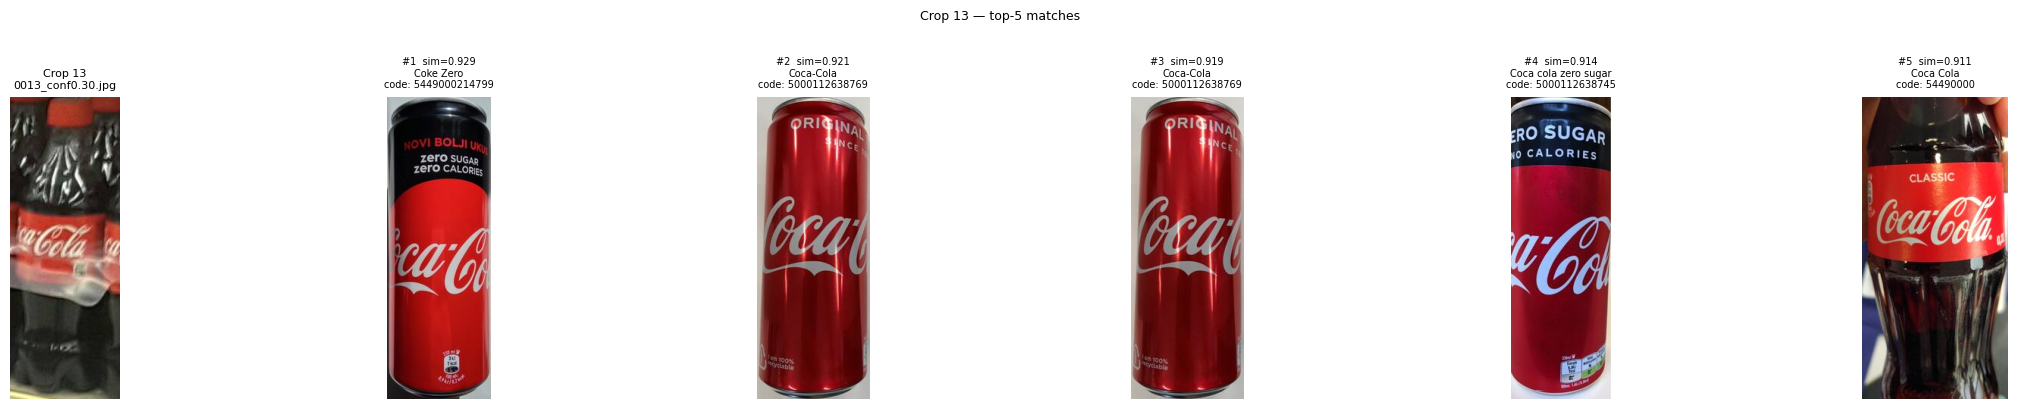


  Crop 13 best matches:
    #1  sim=0.9289  code=5449000214799  name=Coke Zero
         url=https://images.openfoodfacts.org/images/products/544/900/021/4799/front_sr.41.400.jpg
    #2  sim=0.9212  code=5000112638769  name=Coca-Cola
         url=https://images.openfoodfacts.org/images/products/500/011/263/8769/1.400.jpg
    #3  sim=0.9187  code=5000112638769  name=Coca-Cola
         url=https://images.openfoodfacts.org/images/products/500/011/263/8769/3.400.jpg
    #4  sim=0.9138  code=5000112638745  name=Coca cola zero sugar
         url=https://images.openfoodfacts.org/images/products/500/011/263/8745/front_fr.4.400.jpg
    #5  sim=0.9111  code=54490000  name=Coca Cola
         url=https://images.openfoodfacts.org/images/products/000/005/449/0000/front_fr.20.400.jpg



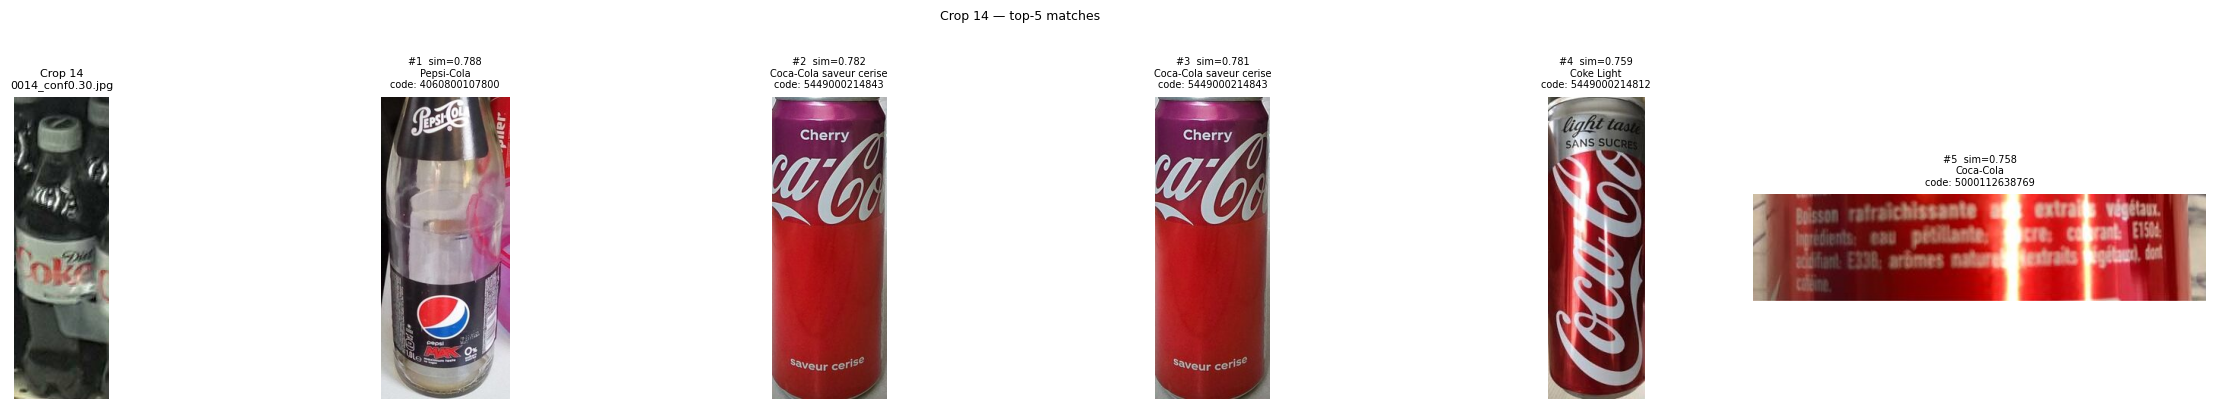


  Crop 14 best matches:
    #1  sim=0.7876  code=4060800107800  name=Pepsi-Cola
         url=https://images.openfoodfacts.org/images/products/406/080/010/7800/front_fr.12.400.jpg
    #2  sim=0.7824  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/18.400.jpg
    #3  sim=0.7814  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/front_fr.74.400.jpg
    #4  sim=0.7593  code=5449000214812  name=Coke Light
         url=https://images.openfoodfacts.org/images/products/544/900/021/4812/8.400.jpg
    #5  sim=0.7581  code=5000112638769  name=Coca-Cola
         url=https://images.openfoodfacts.org/images/products/500/011/263/8769/2.400.jpg



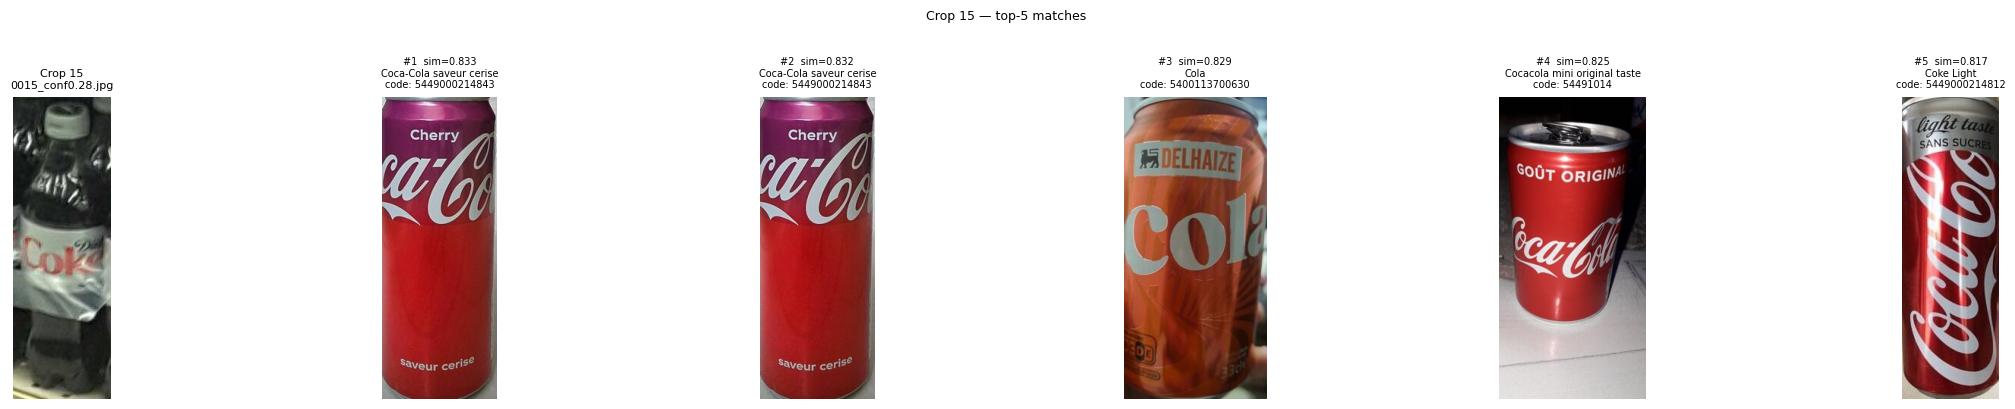


  Crop 15 best matches:
    #1  sim=0.8325  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/18.400.jpg
    #2  sim=0.8322  code=5449000214843  name=Coca-Cola saveur cerise
         url=https://images.openfoodfacts.org/images/products/544/900/021/4843/front_fr.74.400.jpg
    #3  sim=0.8289  code=5400113700630  name=Cola
         url=https://images.openfoodfacts.org/images/products/540/011/370/0630/front_fr.11.400.jpg
    #4  sim=0.8246  code=54491014  name=Cocacola mini original taste
         url=https://images.openfoodfacts.org/images/products/000/005/449/1014/29.400.jpg
    #5  sim=0.8167  code=5449000214812  name=Coke Light
         url=https://images.openfoodfacts.org/images/products/544/900/021/4812/8.400.jpg



In [38]:
for crop_idx, (crop_pil, crop_path, matches) in enumerate(all_results):
    n_matches = len(matches)
    fig, axes = plt.subplots(1, 1 + n_matches, figsize=(4 * (1 + n_matches), 4))
    if n_matches == 0:
        axes = [axes]

    # ── Left panel: the crop ──────────────────────────────────────────────────
    axes[0].imshow(crop_pil)
    axes[0].set_title(f"Crop {crop_idx}\n{crop_path.name}", fontsize=8)
    axes[0].axis("off")

    # ── Right panels: top-K matches ───────────────────────────────────────────
    for rank, (ax, m) in enumerate(zip(axes[1:], matches), start=1):
        match_img = fetch_pil(m["image_url"]) if m["image_url"] else None
        if match_img:
            ax.imshow(match_img)
        else:
            ax.text(0.5, 0.5, "No image", ha="center", va="center", transform=ax.transAxes)

        title = (
            f"#{rank}  sim={m['similarity']:.3f}\n"
            f"{m['product_name']}\n"
            f"code: {m['code']}"
        )
        ax.set_title(title, fontsize=7)
        ax.axis("off")

    plt.suptitle(f"Crop {crop_idx} — top-{n_matches} matches", fontsize=9, y=1.01)
    plt.tight_layout()
    plt.savefig(run_dir / f"{crop_idx:04d}_matches.png", bbox_inches="tight", dpi=120)
    plt.show()
    print()

    # ── Print table ───────────────────────────────────────────────────────────
    print(f"  Crop {crop_idx} best matches:")
    for rank, m in enumerate(matches, 1):
        print(f"    #{rank}  sim={m['similarity']:.4f}  "
              f"code={m['code']}  name={m['product_name']}")
        print(f"         url={m['image_url']}")
    print()

Gewichten aanpassen om te zien of de resultaten verschillen en misschien verbeteren

In [30]:
test_crop_pil = all_results[0][0]

# Dit test voor clip 70%, 50% en 30%, idem voor Florence-2
for cw, fw in [(0.7, 0.3), (0.5, 0.5), (0.3, 0.7)]:
    orig_c, orig_f = CLIP_WEIGHT, FL2_WEIGHT
    CLIP_WEIGHT, FL2_WEIGHT = cw, fw

    top1 = search(test_crop_pil, k=1)
    m    = top1[0] if top1 else {}
    print(f"CLIP={cw} / FL2={fw}  →  {m.get('product_name')}  sim={m.get('similarity', 0):.4f}")

    CLIP_WEIGHT, FL2_WEIGHT = orig_c, orig_f

CLIP=0.7 / FL2=0.3  →  Ophelie  sim=0.8348
CLIP=0.5 / FL2=0.5  →  Ophelie  sim=0.7823
CLIP=0.3 / FL2=0.7  →  Ophelie  sim=0.6178
